# MERFISH S2R1 to Allen CCF slice 675

This notebook aligns the adult mouse brain MERFISH S2R1 sample (83,546 cells)
to annotated Allen Common Coordinate Framework (CCF) coronal slice 675. The
reference has no gene-expression features. spAlignDE therefore discovers
correspondences between ST spatial structures and hierarchical atlas regions,
then refines those correspondences with coarse-to-fine S-LDDMM.

The analysis starts from the canonical AnnData produced by the single-
clustering notebook and returns the same AnnData with pre-aligned coordinates,
final aligned coordinates, Allen labels, and package provenance.

**Fixed-seed reproducibility.** This workflow uses seed `1234`. Launch Python with `PYTHONHASHSEED` set before kernel startup, then keep the documented input order, package versions and configuration fixed. Discrete labels/pairs are expected to match exactly; CUDA coordinates are compared with the documented numerical tolerance.

## Installation and input data

From the repository root:

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,atlas,tutorial]"
```

| Role | Input | Contract |
|---|---|---|
| Query ST | `tutorials/cross_modality/atlas/output/merfish_S2R1_single_clustered.h5ad` | cell-by-gene `X`; coordinates in `obsm["spatial"]`; selected labels in `obs["cluster"]` |
| Atlas annotation | `annotation_10.nrrd` | Allen CCF 2022 annotation volume; this example selects coronal slice 675 |
| Atlas hierarchy | `voxel_count_and_differences.csv` | annotation ID index plus structure name/acronym, hierarchy path, and display color |

Download the Allen CCF 2022 files from the
[Allen Institute annotation release](https://download.alleninstitute.org/informatics-archive/current-release/mouse_ccf/annotation/ccf_2022/)
and place them in `data/allen_ccf_2022/`, or set `SPALIGNDE_ALLEN_CCF_DIR`.
Run the single-clustering notebook first, or set
`SPALIGNDE_CLUSTERED_ST_H5AD` to an equivalent clustered AnnData file.

In [1]:
%matplotlib inline

from pathlib import Path
import json
import os
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

import spAlignDE

WORKFLOW_SEED = 1234
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "atlas" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

clustered_default = OUTPUT_DIR / "merfish_S2R1_single_clustered.h5ad"
CLUSTERED_PATH = Path(os.environ.get("SPALIGNDE_CLUSTERED_ST_H5AD", clustered_default)).expanduser()

public_atlas_dir = PROJECT_ROOT / "data" / "allen_ccf_2022"
ATLAS_DIR = Path(os.environ.get("SPALIGNDE_ALLEN_CCF_DIR", public_atlas_dir)).expanduser()

required_atlas_files = [
    ATLAS_DIR / "annotation_10.nrrd",
    ATLAS_DIR / "voxel_count_and_differences.csv",
]
missing_atlas_files = [str(path) for path in required_atlas_files if not path.is_file()]
if missing_atlas_files:
    raise FileNotFoundError(
        "Allen CCF inputs are missing. Place them under data/allen_ccf_2022 "
        "or set SPALIGNDE_ALLEN_CCF_DIR. Missing: " + ", ".join(missing_atlas_files)
    )

adata = spAlignDE.load_single_sample_data(CLUSTERED_PATH)
if "cluster" not in adata.obs and "banksy_cluster_refined" in adata.obs:
    adata.obs["cluster_raw"] = adata.obs["banksy_cluster"].astype(str).astype("category")
    adata.obs["cluster_refined"] = adata.obs["banksy_cluster_refined"].astype(str).astype("category")
    adata.obs["cluster"] = adata.obs["cluster_refined"].copy()

atlas = spAlignDE.load_allen_ccf_reference(
    ATLAS_DIR / "annotation_10.nrrd",
    ATLAS_DIR / "voxel_count_and_differences.csv",
    slice_index=675,
)

print(f"Query: {adata.n_obs:,} cells × {adata.n_vars:,} genes; {adata.obs['cluster'].nunique()} clusters")
print(f"Reference: Allen CCF slice {atlas.slice_index}; image shape {atlas.shape}")

Query: 83,546 cells × 649 genes; 25 clusters
Reference: Allen CCF slice 675; image shape (800, 1140)


## 1. Build coarse-to-fine ST structure levels

Single-sample BANKSY supplies the finest ST labels. spAlignDE then aggregates
log-transformed expression within each cluster, retains genes explaining 80%
of total gene-wise variance (at least 50 genes), standardizes cluster-average
profiles, and applies Ward linkage. Two coarser partitions precede the final BANKSY partition. Three levels provide the validated coarse-to-fine path. The
structure-pairing score also treats area and thickness as first-class shape
evidence, which helps distinguish narrow laminar regions from broader adjacent
structures. No CA3-specific matching rule is used. The executed output below
is authoritative for the current locked environment.

These levels are ST-only. Allen candidates from hierarchy depths 2–10 remain eligible at every stage; only the ST partition becomes finer.

In [2]:
config = spAlignDE.STAtlasAlignmentConfig(
    n_levels=3,
    minimum_coarse_structures=7,
    variance_fraction=0.8,
    min_genes=50,
    continue_alignment=True,
    continue_max_iterations=10,
    continue_min_pair_gain=1,
    pairing_weight_sdf=0.05,
    pairing_weight_chamfer=0.05,
    pairing_weight_dice=0.20,
    pairing_weight_area=0.50,
    pairing_weight_thickness=0.20,
    continuation_kernel_scale=200,
    continuation_velocity_grid_spacing=50,
    continuation_restore_best_checkpoint=False,
    pairing_dice_soft=0.25,
    device=None,  # automatically uses CUDA when available
)

adata, hierarchy_columns = spAlignDE.build_st_cluster_hierarchy(
    adata,
    config=config,
    cluster_key="cluster",
    copy=False,
)
print("Coarse-to-fine alignment labels:", [*hierarchy_columns, "cluster"])
display(
    pd.DataFrame(
        {
            "label column": [*hierarchy_columns, "cluster"],
            "number of structures": [
                *[adata.obs[column].nunique() for column in hierarchy_columns],
                adata.obs["cluster"].nunique(),
            ],
        }
    )
)

Coarse-to-fine alignment labels: ['cluster_level_k7', 'cluster_level_k16', 'cluster']


,label column,number of structures
0,cluster_level_k7,7
1,cluster_level_k16,16
2,cluster,25


### How to adapt the Atlas configuration

Tune this workflow in order: atlas slice/orientation, ST clustering, hierarchy,
whole-tissue pre-alignment, structure masks and pairs, then deformation.

- `n_levels` adds coarse-to-fine stages. More levels can stabilize narrow
  structures but increase runtime and can propagate a poor coarse match.
- `minimum_coarse_structures` controls initial anatomical anchors. Too few are
  weak; too many make the first stage insufficiently coarse.
- `variance_fraction` and `min_genes` control the expression evidence used to
  merge fine clusters. Inspect every hierarchy level spatially.
- A smaller `prealign_angle_step_degrees` refines angular search at higher
  cost. Expand the scale search only when whole-tissue size remains wrong.
- Pairing weights must be non-negative and sum to one. Area and thickness help
  distinguish narrow laminar structures from broad neighbors; Dice, SDF and
  Chamfer measure spatial agreement. Change weights globally, never for a
  named anatomical structure.
- Raising `pairing_score_threshold` or lowering `pairing_max_asd` makes pair
  acceptance stricter. Inspect the candidate component metrics before changing
  either gate.

`STAtlasAlignmentConfig` does not expose one `kernel_scale`/`grid_step` pair:
the coarse-to-fine workflow uses a validated stage-specific S-LDDMM schedule
internally. Passing the cross-sample `SLDDMMConfig` does not affect Atlas
alignment. Tune the exposed hierarchy, pre-alignment, masks and pairing first;
a custom stage schedule requires an explicit API extension.

If a thin region matches a broader neighbor, check hierarchy level, mask
quality and pre-alignment first. Only then adjust the global area/thickness
balance. The three-level example is a validated starting profile, not a rule for
all cluster counts or atlas slices.

## 2. Align ST to the Allen CCF slice

The package performs four linked operations:

1. Estimate rotation, isotropic scale, and translation by maximizing IoU
   between the whole-ST mask and atlas brain mask; reflection is disabled.
2. Rasterize each ST structure as an adaptive smoothed binary mask and compare
   it with atlas structures derived directly from the annotation hierarchy.
3. Select non-overlapping one-to-one correspondences using a gated composite
   of Dice, signed-distance correlation, Chamfer similarity, area similarity,
   and thickness similarity. Average surface distance is retained as QC.
4. Convert accepted mask pairs to matched signed-distance channels and apply
   coarse-to-fine shooting-based LDDMM.

This notebook always performs a fresh alignment from the clustered AnnData.
No validated-result loader or alignment cache is involved.

The default pairing score is

`0.05 × SDF + 0.05 × Chamfer + 0.20 × Dice + 0.50 × area + 0.20 × thickness`.

These weights sum to one. They emphasize global size and laminar thickness
without a structure-name override; Dice, SDF, and Chamfer still require
spatial agreement. Raw ASD is retained only as an independent QC gate. For
new data, follow the [cross-modality pairing-weight tuning guide](https://dsong-lab.github.io/spAlignDE/tutorials/parameter_tuning.html#cross-modality-pairing-weights)
and change the five weights globally while keeping them non-negative and
normalized to one.

In [3]:
alignment_output = OUTPUT_DIR / "alignment"
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
alignment_start = time.perf_counter()
result = spAlignDE.align_st_to_allen_atlas(
    adata,
    atlas,
    config=config,
    cluster_key="cluster",
    output_dir=alignment_output,
)
if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed_seconds = time.perf_counter() - alignment_start
peak_cuda_gib = (
    torch.cuda.max_memory_allocated() / (1024**3)
    if torch.cuda.is_available()
    else 0.0
)
runtime_metrics = {
    "elapsed_seconds": elapsed_seconds,
    "elapsed_minutes": elapsed_seconds / 60.0,
    "peak_cuda_memory_allocated_gib": peak_cuda_gib,
    "cuda_available": torch.cuda.is_available(),
}
(alignment_output / "end_to_end_runtime_cuda_metrics.json").write_text(
    json.dumps(runtime_metrics, indent=2)
)

print("Mode: fresh package run")
print("Aligned observations:", f"{result.adata.n_obs:,}")
print("Final matched structure pairs:", len(result.matched_pairs))
print(f"Alignment runtime: {runtime_metrics['elapsed_minutes']:.1f} minutes")
print(f"Peak GPU memory allocation: {runtime_metrics['peak_cuda_memory_allocated_gib']:.3f} GiB")

Mode: fresh package run
Aligned observations: 83,546
Scheduled pair counts: [3, 7, 15]
Continuation pair counts: 15→17, 17→17
Final matched structure pairs: 17
Alignment runtime: 13.7 minutes
Peak GPU memory allocation: 0.839 GiB


## 3. Inspect structure correspondences

The three-level package workflow starts with at least seven coarse structures
and then adds intermediate partitions so deformation proceeds through smaller
coarse-to-fine changes. The executed output reports the exact stage and final
pair counts for this fresh run. The complete matched-pair table is shown for
general QC. Automatic pairing uses only spatial masks and the atlas hierarchy;
no shared molecular features or structure-specific override is used.

In [4]:
display(result.stage_summary)

pair_columns = [
    column
    for column in (
        "cluster",
        "candidate_name",
        "pair_type",
        "align_score_gated",
        "dice",
        "area_sim",
        "chamfer_dist",
        "asd",
    )
    if column in result.matched_pairs
]
display(result.matched_pairs[pair_columns].head(20))

,stage,label_col,is_final_stage,n_pairs,lddmm_ran
0,1,cluster_level_k7,False,3,True
1,2,cluster_level_k16,False,7,True
2,3,cluster,True,15,True


,cluster,candidate_name,pair_type,align_score_gated,dice,area_sim,chamfer_dist,asd
0,0,DORsm,leaf,0.538736,0.597163,0.466856,27.431903,28.923761
1,1,L2/3,layer,0.854394,0.767896,0.921190,10.521349,10.497765
2,10,fiber tracts,leaf,0.644582,0.642123,0.577443,25.531828,35.287638
3,11,ILM,leaf,0.698535,0.529214,0.701713,14.088718,15.653557
4,12,PAL,leaf,0.756560,0.784310,0.787109,8.961758,8.773596
5,17,EPI,leaf,0.914665,0.830208,0.988110,3.622646,3.647345
6,18,CA3sp,leaf,0.837205,0.813614,0.781571,1.780189,1.789843
7,19,DG-sg,leaf,0.844326,0.736750,0.853782,3.320263,3.392743
8,2,L6a,layer,0.910835,0.818447,0.979146,6.519452,6.681956
9,20,ARH,leaf,0.614991,0.590718,0.505388,11.373444,14.036967


## 4. Paired-feature mask quality control

Inspect the accepted binary masks themselves before interpreting the
deformation. Blue is the moving ST structure, orange is the Allen target, and
purple is their intersection. The figure shows the six pairs with the highest
global gated score; the complete 17-pair table remains above. Selection is
score-based and does not give any anatomical region a special plotting rule.

Dice measures area overlap, while ASD remains sensitive to displaced
boundaries and width differences in thin structures. These are the same ST and
Allen features accepted by the final matching stage as S-LDDMM channels.


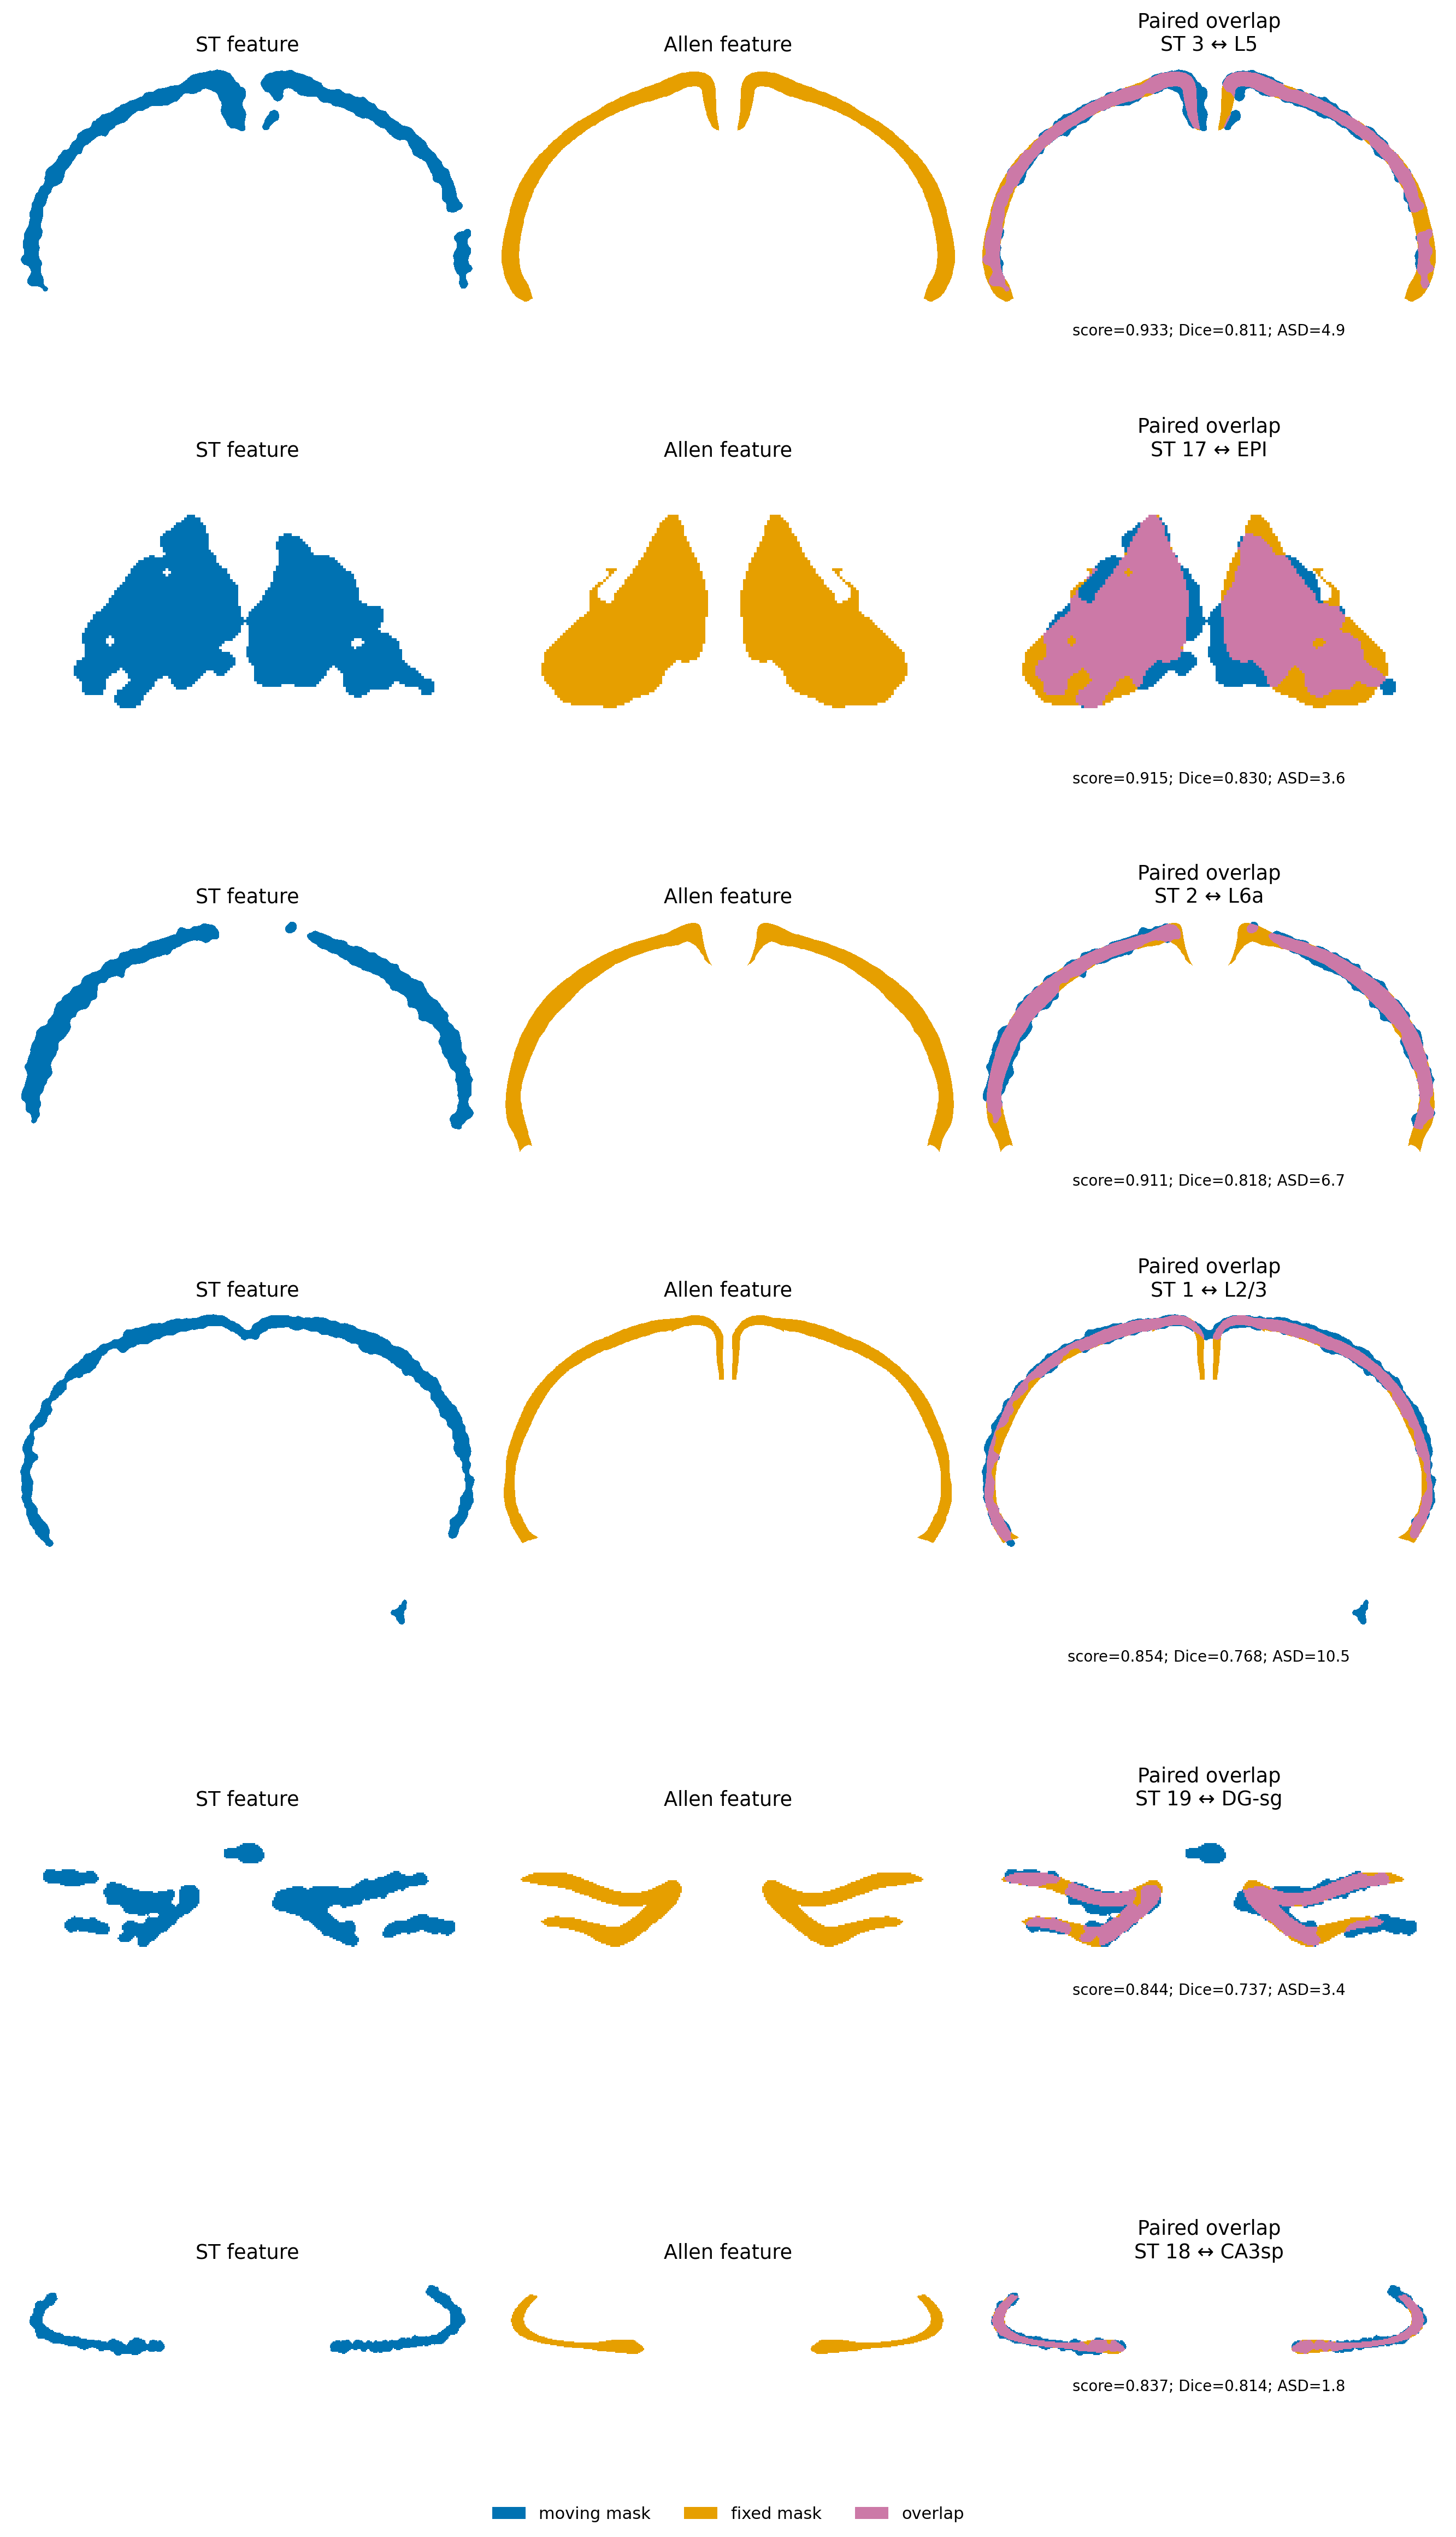

In [5]:
import numpy as np
from matplotlib.patches import Patch

pair_score_column = (
    "align_score_gated" if "align_score_gated" in result.matched_pairs else "align_score"
)
pair_table_qc = (
    result.matched_pairs
    .sort_values(pair_score_column, ascending=False)
    .head(6)
    .reset_index(drop=True)
)

if result.context is None:
    raise RuntimeError("A fresh alignment result with runtime masks is required for this QC.")

continuation = result.context.get("continue_alignment_outputs", [])
if continuation:
    final_mask_result = continuation[-1]["after_match"]["result"]
else:
    stages = result.context.get("iter_stage_outputs", [])
    if not stages:
        raise RuntimeError("No final Atlas matching stage is available.")
    final_mask_result = stages[-1]["result"]

st_masks_qc = final_mask_result["st_masks"]
atlas_annotation_qc = result.atlas.annotation

blue = np.array([0 / 255, 114 / 255, 178 / 255, 1.0])
orange = np.array([230 / 255, 159 / 255, 0 / 255, 1.0])
purple = np.array([204 / 255, 121 / 255, 167 / 255, 1.0])


def parse_atlas_labels(value):
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return [int(item) for item in value]
    text = str(value).strip().replace(" ", "")
    for separator in (";", ","):
        if separator in text:
            return [int(float(item)) for item in text.split(separator) if item]
    return [int(float(text))]


def mask_rgba(mask, color):
    image = np.ones(mask.shape + (4,), dtype=float)
    image[..., 3] = 0.0
    image[mask] = color
    return image


def overlap_rgba(source_mask, target_mask):
    image = np.ones(source_mask.shape + (4,), dtype=float)
    image[:] = [1.0, 1.0, 1.0, 1.0]
    image[target_mask] = orange
    image[source_mask] = blue
    image[source_mask & target_mask] = purple
    return image


fig, axes = plt.subplots(
    len(pair_table_qc),
    3,
    figsize=(12, 3.55 * len(pair_table_qc)),
    constrained_layout=True,
    squeeze=False,
)
for pair_index, row in pair_table_qc.iterrows():
    st_mask = np.asarray(st_masks_qc[str(row["cluster"])]) > 0
    atlas_mask = np.isin(
        atlas_annotation_qc,
        parse_atlas_labels(row["atlas_labels_union"]),
    )
    union = st_mask | atlas_mask
    yy, xx = np.where(union)
    padding = 18
    y0 = max(0, int(yy.min()) - padding)
    y1 = min(union.shape[0], int(yy.max()) + padding + 1)
    x0 = max(0, int(xx.min()) - padding)
    x1 = min(union.shape[1], int(xx.max()) + padding + 1)
    panels = (
        (mask_rgba(st_mask, blue), "ST feature"),
        (mask_rgba(atlas_mask, orange), "Allen feature"),
        (
            overlap_rgba(st_mask, atlas_mask),
            f"Paired overlap\nST {row['cluster']} ↔ {row['candidate_name']}",
        ),
    )
    for axis, (image, title) in zip(axes[pair_index], panels):
        axis.imshow(image[y0:y1, x0:x1], origin="lower", interpolation="nearest")
        axis.set_title(title)
        axis.axis("off")
    axes[pair_index, 2].text(
        0.5,
        -0.05,
        (
            f"score={row[pair_score_column]:.3f}; "
            f"Dice={row['dice']:.3f}; ASD={row['asd']:.1f}"
        ),
        transform=axes[pair_index, 2].transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

fig.legend(
    handles=(
        Patch(facecolor=blue, label="ST mask"),
        Patch(facecolor=orange, label="Allen mask"),
        Patch(facecolor=purple, label="overlap"),
    ),
    loc="lower center",
    ncol=3,
    frameon=False,
)
fig.savefig(FIGURE_DIR / "st_atlas_paired_feature_masks.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_atlas_paired_feature_masks.svg", bbox_inches="tight")
plt.show()


## 5. Shared-color paired-feature overlay before and after S-LDDMM

This is the primary cross-modality pairing QC. Every accepted ST structure and
its paired Allen candidate use the same fixed structure-name color. The left
panel overlays globally pre-aligned ST cells on their selected atlas features;
the right panel repeats the identical pairing after coarse-to-fine S-LDDMM.
Unmatched atlas regions are light gray and unmatched ST cells are dark gray.

Inspect the overlap before deformation as evidence that automatic pairing chose
the intended width, position, and shape. The post-deformation panel shows what
the selected feature channels drove; it should not be used to justify a pair
that was implausible in the pre-aligned panel. The fixed palette comes from the
validated paper notebook and does not change with cluster numbering or pair
order.


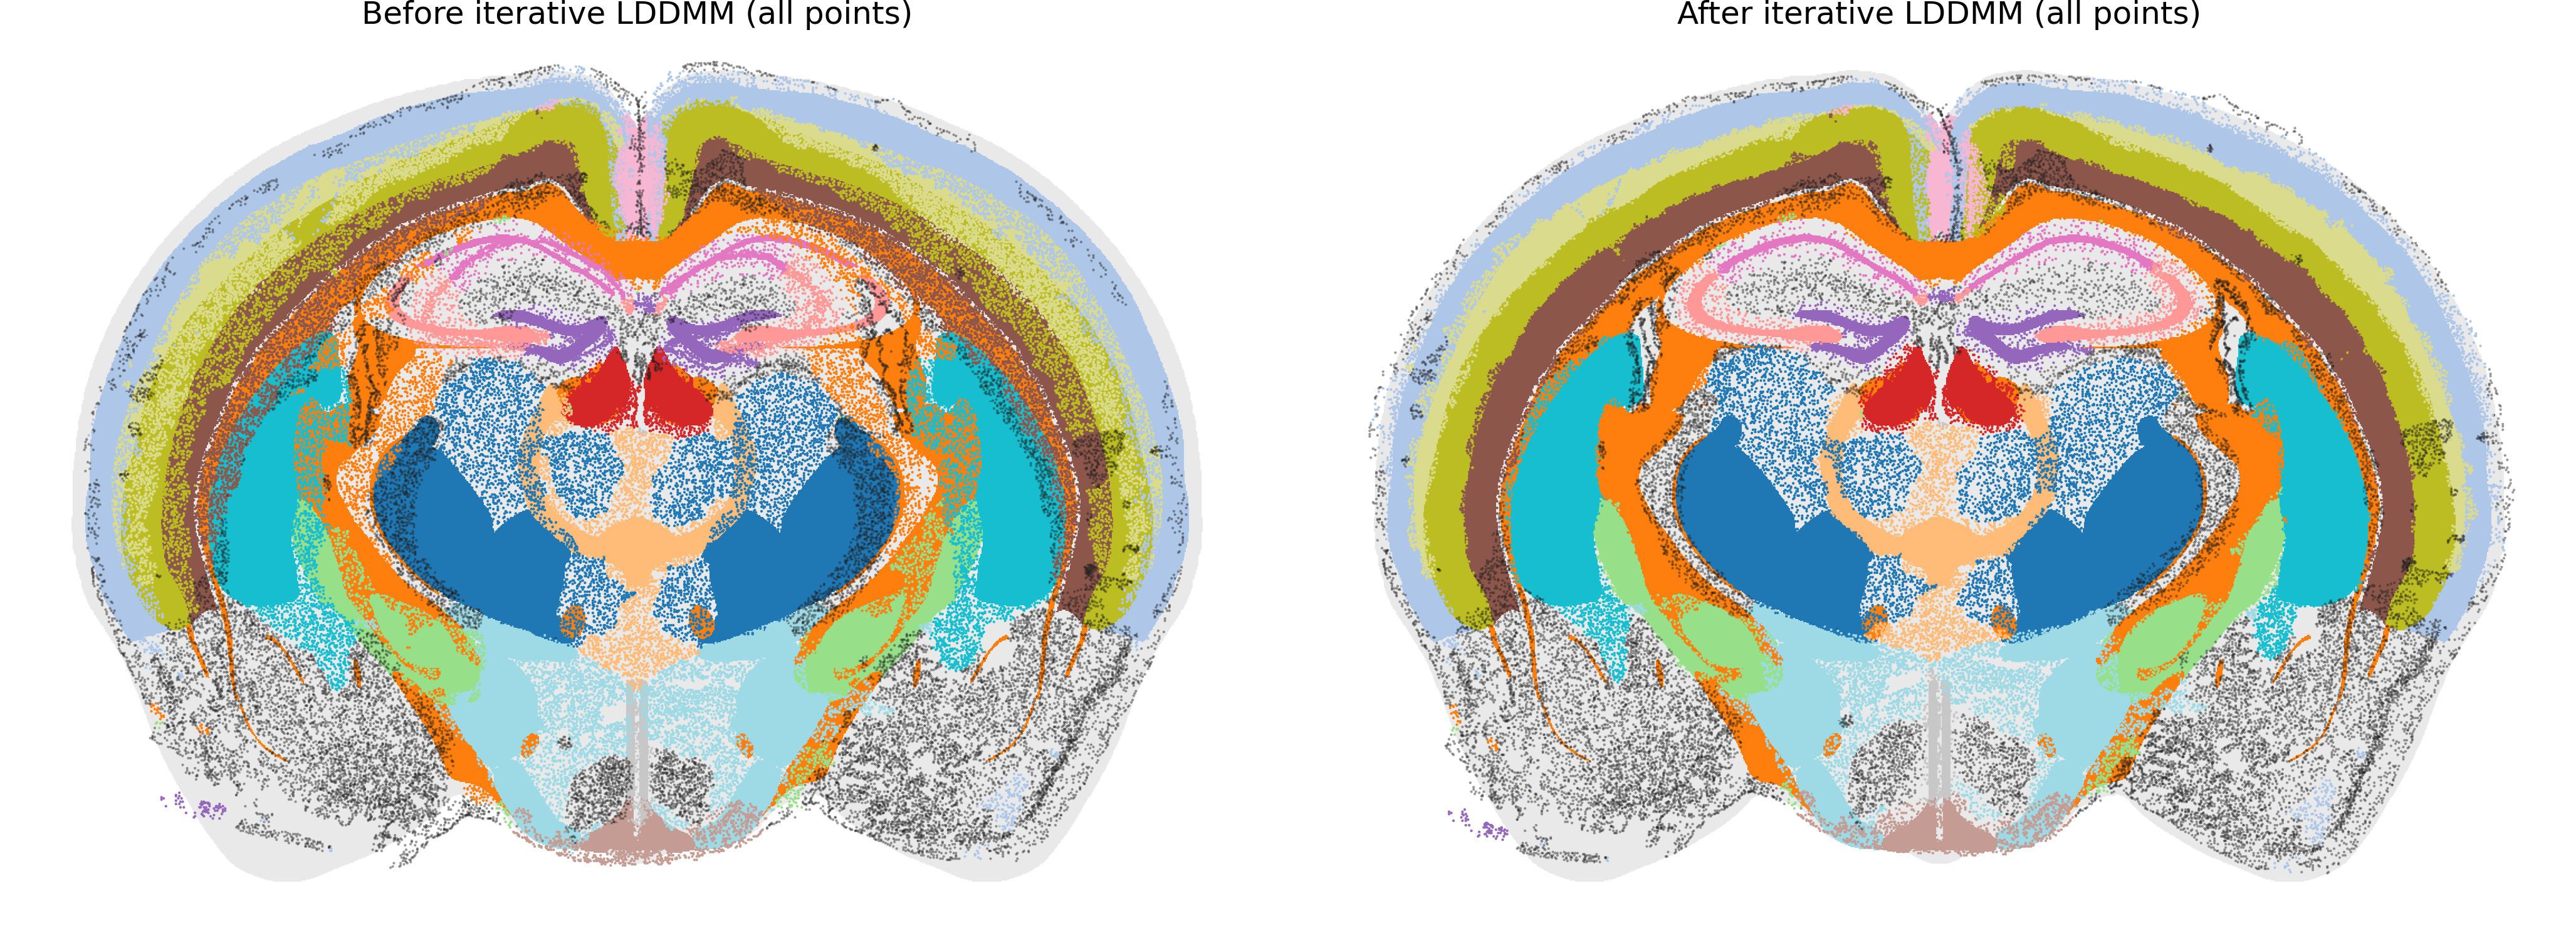

In [6]:
structure_color_map = spAlignDE.load_atlas_structure_color_map()
fig, axes = spAlignDE.plot_st_atlas_alignment(
    result,
    cluster_key="cluster",
    structure_color_map=structure_color_map,
    point_size=1.0,
    figsize=(14, 7),
)
fig.savefig(FIGURE_DIR / "st_to_allen_before_after.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_before_after.svg", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_before_after.pdf", bbox_inches="tight")
plt.show()

## 6. Transfer Allen labels to aligned ST cells

After alignment, each final `(x_aligned, y_aligned)` location samples the
annotation image. Atlas ID 0 is retained as background/unlabeled instead of
being replaced by a nearby region. The executed summary below reports the
fresh package result rather than loading cached paper coordinates.

The two panels use the original notebook's fixed label-color table: label 0 is
white, every Allen label has one reproducible color, and transferred ST labels
reuse exactly those colors.

,value
all ST cells,83546.000000
non-background Allen label,83014.000000
background / unlabeled,532.000000
unlabeled fraction,0.006368


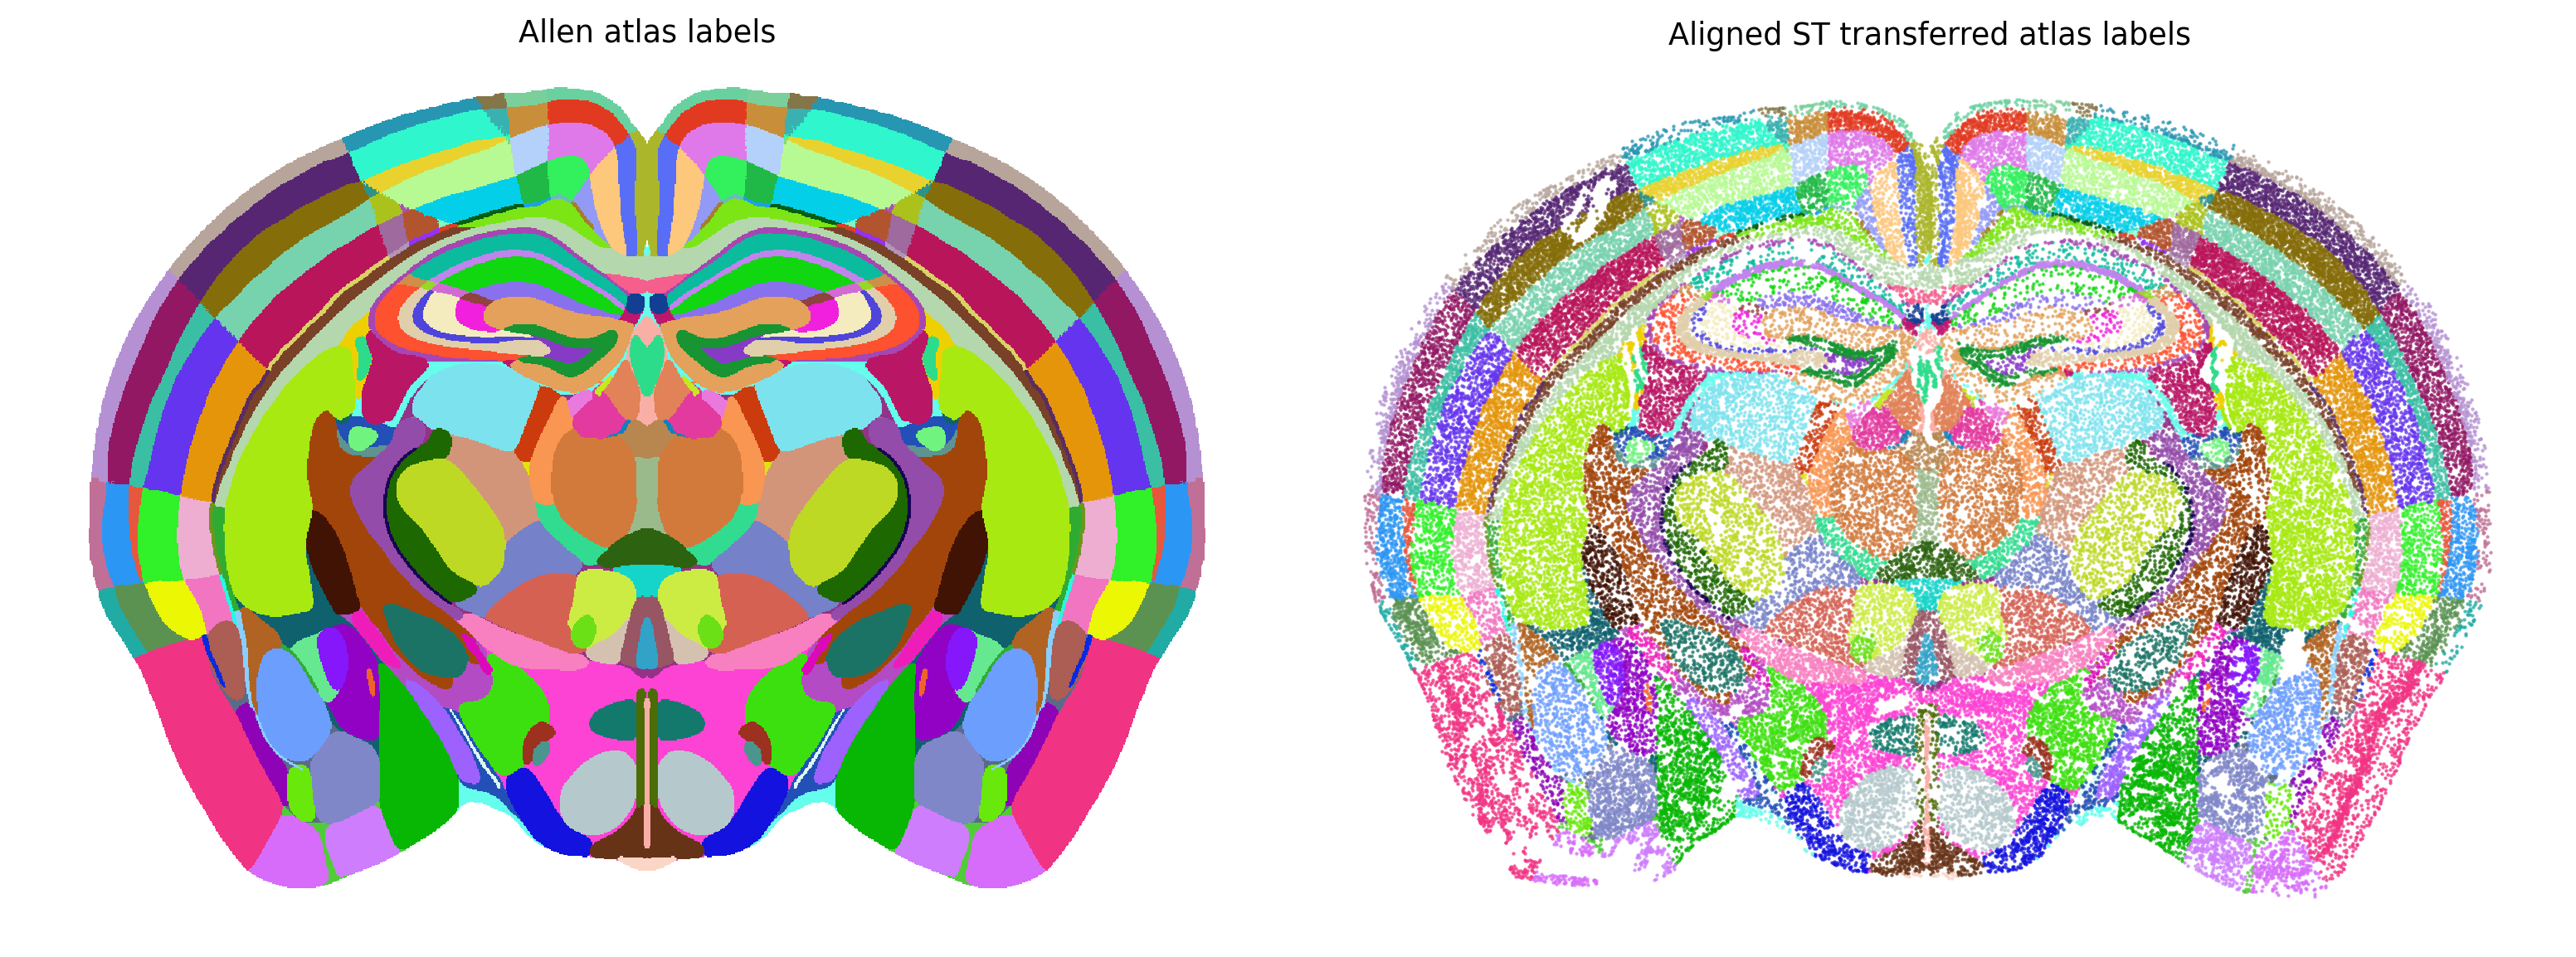

In [7]:
transfer_summary = pd.Series(
    {
        "all ST cells": result.adata.n_obs,
        "non-background Allen label": int(result.adata.obs["atlas_label_transferred"].sum()),
        "background / unlabeled": int((~result.adata.obs["atlas_label_transferred"]).sum()),
        "unlabeled fraction": float((~result.adata.obs["atlas_label_transferred"]).mean()),
    },
    name="value",
)
display(transfer_summary.to_frame())

color_map_path = result.output_dir / (
    f"atlas_z{result.atlas.slice_index}_white_label_color_map_for_transfer_labels.csv"
)
label_color_map = spAlignDE.load_atlas_label_color_map(
    color_map_path,
    atlas=result.atlas,
)
fig, axes = spAlignDE.plot_atlas_label_transfer(
    result,
    color_map=label_color_map,
    point_size=2.0,
    point_alpha=0.8,
    figsize=(14, 7),
)
fig.savefig(FIGURE_DIR / "st_to_allen_label_transfer.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_label_transfer.svg", bbox_inches="tight")
fig.savefig(FIGURE_DIR / "st_to_allen_label_transfer.pdf", bbox_inches="tight")
plt.show()

## 7. Output contract

The returned AnnData preserves `X` and `obsm["spatial"]` and adds:

- `obs["x_prealigned"]`, `obs["y_prealigned"]` — whole-mask IoU result;
- `obs["x_aligned"]`, `obs["y_aligned"]` — final S-LDDMM coordinates;
- `obs["atlas_label_id"]`, `obs["atlas_label_acronym"]`,
  `obs["atlas_label_name"]`, `obs["atlas_label_transferred"]` — sampled Allen
  annotation; and
- `uns["spAlignDE"]["st_to_allen_atlas"]` — parameters and provenance for a
  fresh package run.

`result.matched_pairs` and `result.stage_summary` retain the structure-level
QC tables. A fresh run also writes the aligned H5AD, pair tables, hierarchy
table, and PNG/PDF alignment QC files under the chosen `output_dir`.

In [8]:
coordinate_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
label_columns = [
    "atlas_label_id",
    "atlas_label_acronym",
    "atlas_label_name",
    "atlas_label_transferred",
]
display(result.adata.obs[coordinate_columns + label_columns].head())

metrics_path = result.output_dir / "end_to_end_runtime_cuda_metrics.json"
if metrics_path.is_file():
    metrics = json.loads(metrics_path.read_text())
    print(f"Fresh end-to-end runtime: {metrics['elapsed_minutes']:.1f} minutes")
    print(f"Peak GPU memory allocation: {metrics['peak_cuda_memory_allocated_gib']:.3f} GiB")

,x_prealigned,y_prealigned,x_aligned,y_aligned,atlas_label_id,atlas_label_acronym,atlas_label_name,atlas_label_transferred
cell_id,,,,,,,,
149164679103246548309819743981609972453,10070.702197,2047.091006,10074.934065,2132.782196,961,PIR,Piriform area,True
215843146921706462965382248182021894607,10140.473843,2117.309107,10144.087001,2206.506917,961,PIR,Piriform area,True
230248905804673613678286091156141465134,10122.405859,2064.660145,10125.602976,2153.240190,961,PIR,Piriform area,True
237155298815097057940587033798543926454,10093.291263,2023.639780,10097.143754,2110.298090,961,PIR,Piriform area,True
256099454901769634241742157204636917386,10099.394726,2029.208897,10103.087197,2116.275829,961,PIR,Piriform area,True


Fresh end-to-end runtime: 13.7 minutes
Peak GPU memory allocation: 0.839 GiB
